In [2]:
import requests
import random
import json
import datetime


In [3]:
# make up some clients

n=10

client = ['Client 1 ',
          'Client 1 UK',
          'Client 1 Italy',
          'Client 2',
          'Client 3',
          'Client 4 Site 1',
          'Client 4 Site 2']
adresse = ['ZA Jolimont, 81200, Mazamet, France',
           'Port of England, 728837, London, United Kingdom',
           'Maque products, 887F73, Napoli, Italy'
           'ZI CHaumont, 33230, Bordeaux, France',
           'Bat Cheminnov, 74300, Bladebli, France',
           'Compositadour, 21000, Bayonne, France',
            'Compositadour recycling, 21000, Bayonne, France']
url = 'http://127.0.0.1:8000/Client/'
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'
}

for i,j in zip(client,adresse):
    data = {'Client_nom':i,
            'Client_adresse':j}
    response = requests.post(url, headers=headers, data=json.dumps(data))


In [4]:
# make up some analysis

n = 200

names = ['UV',"DLS","RAMAN"]
material = ["OGD",'W','W3','W10']
operateur = ['WL','LB','TB','LC','RS']
for i in range(n):

    m = random.choice(material)
    week = random.randint(1,55)
    sample = random.choice(['A','B','C','D','E','F','G','H'])
    code = f'{m}_{week}_{sample}'

    year = random.choice([2023,2024,2025])

    analysis = random.choice(names)
    if analysis == 'UV':
        path = f'Suivi_prod/CQ{year}/{m}/{str(year)[:-2]}{week}{sample}'
    elif analysis == 'RAMAN':
        path = f'Dossier_autre/{year}/{m}_{week}{sample}'
    else:
        path = f'Transfert_labo/{random.choice(operateur)}/{m}{str(year)[:-2]}{week}'

    data = {'Analyse_path_to_raw':path,
            'Analyse_code':code}
    
    url = 'http://127.0.0.1:8000/analyses/'
    headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }

    response = requests.post(url, headers=headers, data=json.dumps(data))
    # print(response.json())

In [5]:
response.json()

{'detail': [{'type': 'missing',
   'loc': ['body', 'Analyse_name'],
   'msg': 'Field required',
   'input': {'Analyse_path_to_raw': 'Suivi_prod/CQ2024/W10/2048C',
    'Analyse_code': 'W10_48_C'}},
  {'type': 'missing',
   'loc': ['body', 'Analyse_subname'],
   'msg': 'Field required',
   'input': {'Analyse_path_to_raw': 'Suivi_prod/CQ2024/W10/2048C',
    'Analyse_code': 'W10_48_C'}},
  {'type': 'missing',
   'loc': ['body', 'Analyse_details'],
   'msg': 'Field required',
   'input': {'Analyse_path_to_raw': 'Suivi_prod/CQ2024/W10/2048C',
    'Analyse_code': 'W10_48_C'}},
  {'type': 'missing',
   'loc': ['body', 'Analyses_data'],
   'msg': 'Field required',
   'input': {'Analyse_path_to_raw': 'Suivi_prod/CQ2024/W10/2048C',
    'Analyse_code': 'W10_48_C'}}]}

In [6]:
# make up some matieres premieres
import requests
import json
import random
import string
import numpy as np
import pandas as pd
from datetime import datetime

def generate_random_string(length=5):
    characters = string.ascii_letters + string.digits  # Includes A-Z, a-z, 0-9
    return ''.join(random.choices(characters, k=length))

def generate_code(nom):
    if nom == 'THF':
        return 'CW_001'
    elif nom == 'Carbone':
        return 'CW_002'
    else:
        return 'CW_003'
def apply_unit(nom):
    if nom == 'THF':
        return 'L'
    elif nom == 'Carbone':
        return 'kg'
    else:
        return 'kg'

def get_date(data):
    return datetime.strptime(data['MP_date_reception'],'%Y-%m-%d')
  
def make_up_MP():
    url = 'http://127.0.0.1:8000/matieres_premieres/'
    headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }
    all_data=list()
    date_range = pd.date_range(start='2023-01-01', end='2025-01-10')

    for i in range(200):
        nom = random.choice(['THF','Carbone','Potassium'])
        date = np.random.choice(date_range, replace=False)
        print(date.astype(str)[:10])
        data = {'MP_nom':nom,
                'MP_codeCW':generate_code(nom),
                'MP_ref_fournisseur':generate_random_string(length=20),
                'MP_date_reception':date.astype(str)[:10],
                'MP_quantite':0,#random.randint(1,1000),
                'MP_unite':apply_unit(nom),
                'MP_Analyses':'codes_analyses_separated_by_commas'}
        all_data.append(data)

    sorted_all_data = sorted(all_data,key=get_date)

    for data in sorted_all_data:
        response = requests.post(url, headers=headers, data=json.dumps(data))


make_up_MP()

2024-08-07
2024-08-13
2024-02-07
2024-01-05
2024-07-08
2023-12-04
2024-08-31
2023-12-03
2023-10-01
2023-10-19
2024-05-19
2023-07-17
2024-04-30
2023-09-09
2024-11-30
2024-02-01
2024-04-04
2023-12-08
2024-11-02
2023-05-01
2024-04-17
2024-11-17
2023-09-28
2024-05-11
2024-11-12
2024-02-16
2023-10-19
2023-03-08
2024-05-27
2023-02-02
2024-10-04
2023-05-11
2023-12-06
2025-01-03
2024-01-26
2023-02-21
2023-09-27
2024-09-16
2023-06-24
2024-03-31
2024-03-01
2024-09-10
2024-09-12
2024-07-25
2024-03-03
2024-01-25
2023-05-20
2024-10-12
2024-03-12
2023-11-27
2024-11-20
2024-10-09
2023-12-25
2023-10-24
2024-11-05
2023-12-30
2024-12-22
2023-11-06
2023-11-07
2024-08-22
2024-11-23
2024-12-20
2023-05-22
2023-08-01
2023-01-21
2024-01-18
2024-03-26
2023-12-31
2023-03-02
2024-03-10
2023-12-22
2024-01-15
2023-09-02
2024-03-17
2023-02-07
2023-09-25
2024-07-23
2023-11-17
2024-12-03
2024-08-03
2024-06-19
2023-12-28
2023-01-07
2023-01-08
2023-02-19
2024-10-15
2024-06-14
2024-10-31
2024-01-09
2023-06-29
2024-09-03

In [7]:
# make up some KC8
import pandas as pd
import numpy as np
import random
import requests
import json


def get_date(data):
    return datetime.strptime(data['Batch_KC8_date'],'%Y-%m-%d')


def make_up_KC8():
        date_range = pd.date_range(start='2023-01-01', end='2025-01-10')
        headers = {
        'accept': 'application/json',
        'Content-Type': 'application/json'}
        d = pd.DataFrame(requests.get('http://127.0.0.1:8000/matieres_premieres/', headers=headers).json())


        all_data = list()
        for i in range(200):
                date = np.random.choice(date_range, replace=False)+pd.DateOffset(hours=0)
                debut = date + pd.DateOffset(hours=12)
                fin = debut + pd.DateOffset(hours=random.randint(1,3))
                p = random.choice(d.loc[d.MP_nom == 'Potassium','MP_ref_fournisseur'].values)
                c = random.choice(d.loc[d.MP_nom == 'Carbone','MP_ref_fournisseur'].values)


                data = {"Batch_KC8_name": f"K{str(date)[2:4]}{date.isocalendar()[1]:02d}",
                        "Batch_KC8_date":str(date)[:10],
                        "Batch_KC8_Technicien":random.choice(['WL','LB','TB','LC','RS']),
                        "Batch_KC8_K_batch":p,
                        "Batch_KC8_C_batch":c,
                        "Batch_KC8_masse":random.choice([200,300]),
                        "Batch_KC8_Temperature":random.choice([50,60,70]),
                        "Batch_KC8_Agitation":random.choice([230,250,300]),
                        "Batch_KC8_heure_debut":str(debut),
                        "Batch_KC8_heure_fin":str(fin),
                        "Batch_KC8_room_HR":random.randint(20,30),
                        "Batch_KC8_room_T":random.randint(1,3)/10,
                        "Batch_KC8_Stock":random.randint(0,2),
                        "Batch_KC8_Analyses":'codes_analyses_separated_by_commas'}
                all_data.append(data)
    
        sorted_all_data = sorted(all_data,key=get_date)
        url = 'http://127.0.0.1:8000/KC8/'
        for data in sorted_all_data:
                response = requests.post(url, headers=headers, data=json.dumps(data))
    
make_up_KC8()

In [8]:
# make up some OGD
import pandas as pd
import numpy as np
import random
import requests
import json


def get_date(data):
    return datetime.strptime(data['Batch_OGD_date'],'%Y-%m-%d')


def make_up_OGD():
        date_range = pd.date_range(start='2023-01-01', end='2025-01-10')
        headers = {
            'accept': 'application/json',
            'Content-Type': 'application/json'
            }
        d = pd.DataFrame(requests.get('http://127.0.0.1:8000/KC8/', headers=headers).json())

        all_data = list()
        for i in range(200):
            date = np.random.choice(date_range, replace=False)+pd.DateOffset(hours=0)
            debut = date + pd.DateOffset(hours=12)
            fin = debut + pd.DateOffset(days=6)
            nom = random.choice(['THF','Carbon','Potassium'])
            p = random.choice(d.loc[:,'Batch_KC8_name'].values)

            data = {"Batch_OGD_name":  f"OGD{str(date)[2:4]}{date.isocalendar()[1]:02d}-{random.choice(['A','B','C','D'])}",
                    "Batch_OGD_date":str(date)[:10],
                    "Batch_OGD_Technicien":random.choice(['WL','LB','TB','LC','RS']),
                    "Batch_OGD_KC8_batch":p,
                    "Batch_OGD_KC8_masse":20,
                    "Batch_OGD_THF_batch":generate_random_string(),
                    "Batch_OGD_THF_Volume":random.choice([300,400]),
                    "Batch_OGD_Temperature":random.choice([50,60,70]),
                    "Batch_OGD_Agitation":random.choice([230,260,300]),
                    "Batch_OGD_heure_debut":str(debut),
                    "Batch_OGD_heure_fin":str(fin),
                    "Batch_OGD_room_HR":random.randint(20,30),
                    "Batch_OGD_room_T":random.randint(1,3)/10,
                    "Batch_OGD_Stock":random.randint(1,3),
                    "Batch_OGD_Analyses":'codes_analyses_separated_by_commas'}
            all_data.append(data)

        sorted_all_data = sorted(all_data,key=get_date)
        url = 'http://127.0.0.1:8000/OGD/'
        for data in sorted_all_data:
                response = requests.post(url, headers=headers, data=json.dumps(data))
make_up_OGD()

In [9]:
# make up some product


operateur = ['WL','LB','TB','LC','RS']
products = ['EpoR','EpoF','W10','W10NC','W20']
url = 'http://127.0.0.1:8000/OGD/'
headers = { 'accept': 'application/json',
            'Content-Type': 'application/json'}
response = requests.get(url,headers=headers)
list_OGD = [(a['Batch_OGD_name'],a['Batch_OGD_heure_fin']) for a in response.json()]


for i in range(20):
    batch_OGD = random.choice(list_OGD)
    name = f"{random.choice(products)}-"+batch_OGD[1][2:4]+f"{datetime.strptime(batch_OGD[1][:10],"%Y-%m-%d").isocalendar()[1]:02}"

    data = {
        "Batch_Produit_ref_CW" :name,
        "Batch_Produit_date" :batch_OGD[1][:10],
        "Batch_Produit_Technicien" :random.choice(operateur),
        "Batch_Produit_OGD_batch" :batch_OGD[0],
        "Batch_Produit_OGD_Qte" :random.randint(10,20),
        "Batch_Produit_stabilisant_bacth" :"",
        "Batch_Produit_stabilisant_Qte" :random.randint(1,5),
        "Batch_produit_stock" : random.randint(10,90)/10,
        "Batch_Produit_Analyses" :"",
    }
    url = 'http://127.0.0.1:8000/Produit/'

    response = requests.post(url,headers=headers,data=json.dumps(data))

In [10]:
response = requests.post(url,headers=headers,data=json.dumps(data))

response.content

b'{"detail":"This batch already registered (error(mysql.connector.errors.IntegrityError) 1062 (23000): Duplicate entry \'W20-2437\' for key \'batch_produit.Batch_Produit_ref_CW\'\\n[SQL: INSERT INTO `Batch_produit` (`Batch_Produit_ref_CW`, `Batch_Produit_date`, `Batch_Produit_Technicien`, `Batch_Produit_OGD_batch`, `Batch_Produit_OGD_Qte`, `Batch_Produit_stabilisant_bacth`, `Batch_Produit_stabilisant_Qte`, `Batch_produit_stock`, `Batch_Produit_Analyses`) VALUES (%(Batch_Produit_ref_CW)s, %(Batch_Produit_date)s, %(Batch_Produit_Technicien)s, %(Batch_Produit_OGD_batch)s, %(Batch_Produit_OGD_Qte)s, %(Batch_Produit_stabilisant_bacth)s, %(Batch_Produit_stabilisant_Qte)s, %(Batch_produit_stock)s, %(Batch_Produit_Analyses)s)]\\n[parameters: {\'Batch_Produit_ref_CW\': \'W20-2437\', \'Batch_Produit_date\': datetime.datetime(2024, 9, 9, 0, 0), \'Batch_Produit_Technicien\': \'LC\', \'Batch_Produit_OGD_batch\': \'OGD2436-C\', \'Batch_Produit_OGD_Qte\': 20.0, \'Batch_Produit_stabilisant_bacth\': \'

In [11]:
json.dumps(data)

'{"Batch_Produit_ref_CW": "W20-2437", "Batch_Produit_date": "2024-09-09", "Batch_Produit_Technicien": "LC", "Batch_Produit_OGD_batch": "OGD2436-C", "Batch_Produit_OGD_Qte": 20, "Batch_Produit_stabilisant_bacth": "", "Batch_Produit_stabilisant_Qte": 5, "Batch_produit_stock": 8.3, "Batch_Produit_Analyses": ""}'

In [12]:
# make up some envoi
import pandas as pd
import numpy as np
import random
import requests
import json



def get_date(data):
    return datetime.strptime(data['Envoi_date_commande'],'%Y-%m-%d')


client = ['Client 1 ',
          'Client 1 UK',
          'Client 1 Italy',
          'Client 2',
          'Client 3',
          'Client 4 Site 1',
          'Client 4 Site 2']

def make_up_Envoi():
    date_range = pd.date_range(start='2023-01-01', end='2025-01-10')
    headers = {
        'accept': 'application/json',
        'Content-Type': 'application/json'
        }

    all_data = list()
    for i in range(50):
        date = np.random.choice(date_range, replace=False)
        date_prevu = date+pd.DateOffset(days=random.randint(10,16))
    
        nom = random.choice(client)
        p = random.choice(['W2','W2NC','W3','W3NC','W10','W10NC','EpoF','EpoC'])
        emb = random.choice(['sac','bouteille','fiole','bidon'])

        data = {"Envoi_date_commande":str(date)[:10],
                "Envoi_client_name":nom,
                "Envoi_produit_name":p,
                "Envoi_produit_batch":None,
                "Envoi_produit_Qte":random.randint(3,12),
                "Envoi_produit_emballage":emb,
                "Envoi_date_prevu":str(date_prevu),
                "Envoi_date_effective":None,
                "Envoi_code_coli":None,
                "Envoi_retour_client":None,
                }
        all_data.append(data)

        sorted_all_data = sorted(all_data,key=get_date)
        url = 'http://127.0.0.1:8000/Envoi/'
        for data in sorted_all_data:
                response = requests.post(url, headers=headers, data=json.dumps(data))
     
     


make_up_Envoi()

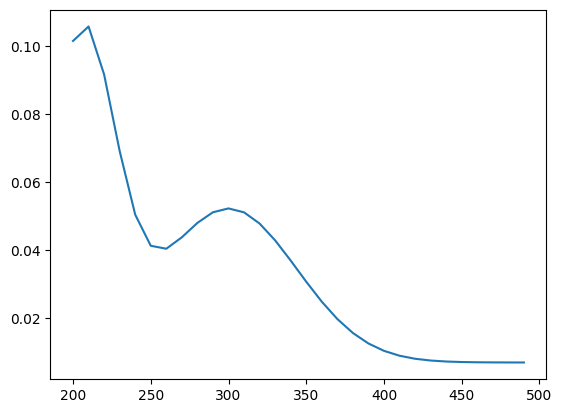

In [18]:
# make up some UV analyse

    # get OGD batch names
import requests
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'
}
response = requests.get('http://127.0.0.1:8000/OGD/', headers=headers)
OGDs = [a['Batch_OGD_name'] for a in response.json()]

    # create cruves
from scipy import stats 
import matplotlib.pyplot as plt

def make_curve():
    # Generate the data
    array1 = stats.norm.pdf(range(10, 40), random.choice(np.arange(10,12,0.2)), random.choice(np.arange(2,3,0.1)))
    array2 = stats.norm.pdf(range(30), 10, random.choice(np.arange(2,5,0.2)))

    # Reshape the arrays to 2D (add an extra axis)
    array1 = array1.reshape(1, -1)  # Shape: (1, n)
    array2 = array2.reshape(1, -1)  # Shape: (1, n)

    # Concatenate along axis=1
    result = np.concatenate([array1, array2]).T
    return result.mean(axis=1) + random.choice(np.arange(0.005,0.020,0.001))

plt.plot(np.arange(200,500,10),make_curve())
curve = {str(x): y for x, y in zip(np.arange(200,500,10),make_curve())}

    # populate db
for i, name in enumerate(OGDs):

    curve = {str(x): y for x, y in zip(np.arange(200,500,10),make_curve())}
    data=dict({'Analyses_id' : i,
            'Analyse_name' : name,
            'Analyse_subname' : 'UV',
            'Analyse_details' : {'dillution':f'1:{random.choice([5,10,20])}','centrifuge':random.choice([True,False])},
            'Analyses_data' :curve})
    response = requests.post('http://127.0.0.1:8000/analyses/', headers=headers,data=json.dumps(data))
    # break

In [17]:
response.content

b'{"detail":[{"type":"missing","loc":["body","Analyse_name"],"msg":"Field required","input":{"Analyses_UV_id":147,"Analyse_UV_name":"OGD2501-C","Analyse_UV_subname":"UV","Analyse_UV_details":{"dillution":"1:5","centrifuge":false},"Analyses_UV_data":{"200":0.08148372439501324,"210":0.08741676282970738,"220":0.08556181405452938,"230":0.07782060757780748,"240":0.0682193393749992,"250":0.06076581548375708,"260":0.05762807603460246,"270":0.05860914471925502,"280":0.061833072036778486,"290":0.0649084271475127,"300":0.06589907005156355,"310":0.06382696552428099,"320":0.058734739052714965,"330":0.05144483971111742,"340":0.04316556746447482,"350":0.03508789119280113,"360":0.028091533177623487,"370":0.02262143285802462,"380":0.018723623819460442,"390":0.016177069976525085,"400":0.01464553346209184,"410":0.013795263165523786,"420":0.013358623895006163,"430":0.013150900883928835,"440":0.013059247298045154,"450":0.013021705486261572,"460":0.013007419842640611,"470":0.01300236670470956,"480":0.01300

In [14]:
# make up some raman analysis



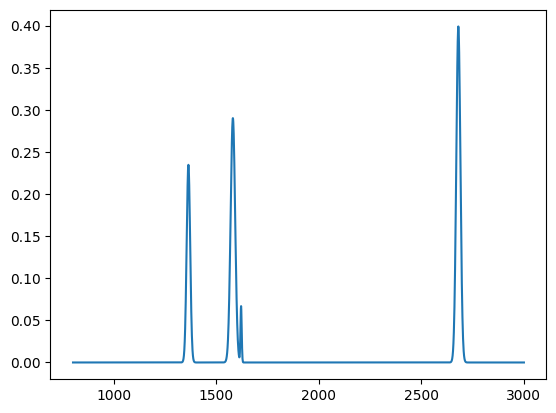

In [19]:
import numpy as np
from scipy import stats
import random


def generate_raman():
    # Generate the arrays
    array1 = 5* stats.norm.pdf(range(1300, 1400), random.choice(np.arange(1345, 1365, 1)), random.choice(np.arange(8, 10, 0.5)))
    array2 = 8* stats.norm.pdf(range(1500, 1660), 1580, random.randint(10, 20))
    array3 = 0.5*stats.norm.pdf(range(1580, 1660), 1620, random.randint(2, 5))
    array4 = 10*stats.norm.pdf(range(2500, 2800), 2680, random.randint(8, 12))

    # Determine the total length needed
    total_length = 3000 - 800 + 1  # From 800 to 3000 inclusive

    # Create zero-padded arrays of the total length
    padded_array1 = np.zeros(total_length)
    padded_array2 = np.zeros(total_length)
    padded_array3 = np.zeros(total_length)
    padded_array4 = np.zeros(total_length)

    # Insert the original arrays into the padded arrays at the correct positions
    padded_array1[1300-800:1400-800] = array1
    padded_array2[1500-800:1660-800] = array2
    padded_array3[1580-800:1660-800] = array3
    padded_array4[2500-800:2800-800] = array4

    # Reshape the arrays to 2D (add an extra axis)
    padded_array1 = padded_array1.reshape(1, -1)  # Shape: (1, total_length)
    padded_array2 = padded_array2.reshape(1, -1)  # Shape: (1, total_length)
    padded_array3 = padded_array3.reshape(1, -1)  # Shape: (1, total_length)
    padded_array4 = padded_array4.reshape(1, -1)  # Shape: (1, total_length)

    # Concatenate along axis=1 and transpose
    result = np.concatenate([padded_array1, padded_array2,padded_array3,padded_array4]).T
    return np.sum(result,axis=1)
plt.plot(range(800,3001),generate_raman())



# make up some UV analyse

    # get OGD batch names
import requests
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'
}
response = requests.get('http://127.0.0.1:8000/OGD/', headers=headers)
OGDs = [a['Batch_OGD_name'] for a in response.json()]

curve = {str(x): y for x, y in zip(range(800,3001),generate_raman())}

    # populate db
for i, name in enumerate(OGDs):

    curve = {str(x): y for x, y in zip(range(800,3001),generate_raman())}
    data=dict({'Analyses_id' : i,
            'Analyse_name' : name,
            'Analyse_subname' : 'RAMAN',
            'Analyse_details' : {'group1_nbr':'230','group1_indic1':'ex D/G','group1_indic2':'ex G/2D','group2_indiv':'30','group2_indic1':'ex D/G','group2_indic2':'ex G/2D'},
            'Analyses_data' :curve})
    response = requests.post('http://127.0.0.1:8000/analyses/', headers=headers,data=json.dumps(data))
    # break